# SEB comparison: free 2stream vs free raytracer vs nudged raytracer

All runs are no-aerosol, zero-wind.

- **1D free**: `no_aerosols_zero_wind` 2stream (control)
- **3D free**: `no_aerosols_zero_wind` raytracer (free-running)
- **3D nudged**: `mean_state_nudge_3600s` raytracer (thl/qt nudged toward 1D mean state)

Science question: when the raytracer is forced onto the 1D mean state (and LWP gap widens),
does the SEB change? If LE increases in the nudged run, more moisture is available for
clouds — but this contradicts the nudging direction (we're forcing it *onto* the 1D mean,
which should constrain qt). Any SEB difference must therefore come from the RT effect on
surface radiation (more cloud shading → lower SW↓ → changes in partitioning).

In [22]:
import os, pickle, sys, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from cass_analysis import (
    load_stats_ensemble,
    conditioned_means_ensemble,
    seb_residual, bowen_ratio, evaporative_fraction,
    plot_seb_timeseries, plot_seb_residual, plot_flux_conditioned,
    _to_plottime,
    FLUX_COLORS, RT_STYLE, RT_LABEL,
    rho, cp, Lv,
)
from catalog import make_runset

In [23]:
N_REPS = 4

KEY_CTRL  = "no_aerosols_zero_wind"   # 2stream free AND raytracer free
KEY_NUDGE = "mean_state_nudge_3600s"  # raytracer nudged only

# Style for the three run types (nudged gets its own entry)
STYLE = {
    "1D free":    dict(color="C0", ls="-",  lw=1.5),
    "3D free":    dict(color="C1", ls="--", lw=1.5),
    "3D nudged":  dict(color="C2", ls=":",  lw=1.8),
}
LABEL = {
    "1D free":   "1D free (2stream)",
    "3D free":   "3D free (raytracer)",
    "3D nudged": r"3D nudged ($\tau = 3600\,\mathrm{s}$)",
}

In [24]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    rs_ctrl  = make_runset(KEY_CTRL,  n_reps=N_REPS)
    rs_nudge = make_runset(KEY_NUDGE, n_reps=N_REPS)

dirs_2s    = rs_ctrl.dirs.get("2stream",   [])
dirs_rt    = rs_ctrl.dirs.get("raytracer", [])
dirs_nudge = rs_nudge.dirs.get("raytracer", [])

print(f"2stream reps  : {len(dirs_2s)}")
print(f"free RT reps  : {len(dirs_rt)}")
print(f"nudged RT reps: {len(dirs_nudge)}")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    s2s_mean,    s2s_std    = load_stats_ensemble(dirs_2s)
    srt_mean,    srt_std    = load_stats_ensemble(dirs_rt)
    snudge_mean, snudge_std = load_stats_ensemble(dirs_nudge)

# Aligned time axis
nt = min(s2s_mean["t_sec"].shape[0],
         srt_mean["t_sec"].shape[0],
         snudge_mean["t_sec"].shape[0])

t_local = s2s_mean["t_local"][:nt]
t_num   = _to_plottime(t_local)

print(f"\nCommon time range: {t_local[0]} → {t_local[-1]}  (nt={nt})")

2stream reps  : 4
free RT reps  : 4
nudged RT reps: 4

Common time range: 2005-07-24 05:30:00 → 2005-07-24 19:19:59.999999999  (nt=167)


## 1. SEB component timeseries — all three runs

One subplot per flux component (H, LE, G, Rnet) so differences are legible.

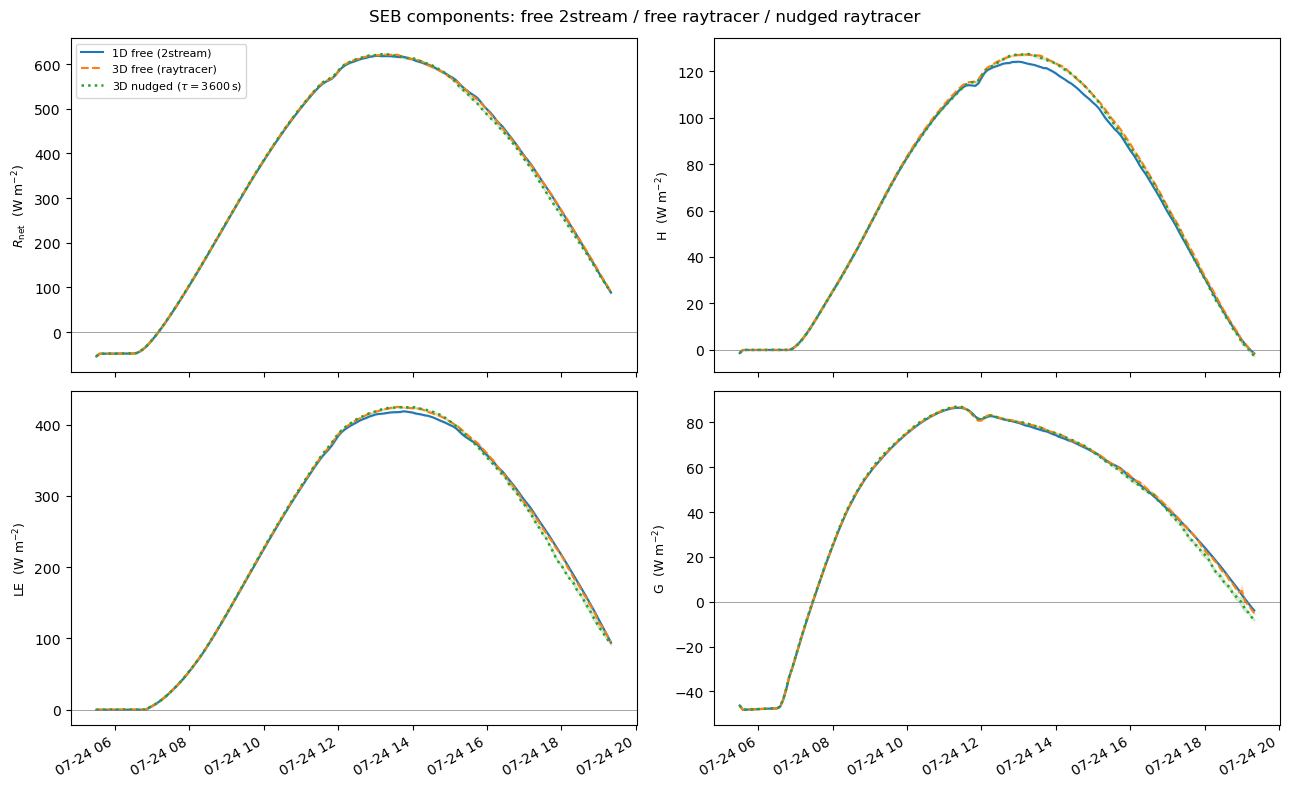

Saved seb_mean_state_nudge_components.pdf


In [25]:
fluxes = ["Rnet", "H", "LE", "G"]
flux_labels = {"Rnet": r"$R_\mathrm{net}$", "H": "H", "LE": "LE", "G": "G"}
flux_units  = "W m$^{-2}$"

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)

run_data = [
    ("1D free",   s2s_mean,    s2s_std),
    ("3D free",   srt_mean,    srt_std),
    ("3D nudged", snudge_mean, snudge_std),
]

for ax, flux in zip(axes.flat, fluxes):
    for run_key, sm, ss in run_data:
        y    = sm[flux][:nt]
        yerr = ss[flux][:nt] if ss.get(flux) is not None else None
        sty  = STYLE[run_key]
        ax.plot(t_num, y, label=LABEL[run_key], **sty)
        if yerr is not None:
            ax.fill_between(t_num, y - yerr, y + yerr,
                            color=sty["color"], alpha=0.15)
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_ylabel(f"{flux_labels[flux]}  ({flux_units})", fontsize=9)
    ax.xaxis_date()
    ax.figure.autofmt_xdate()

axes.flat[0].legend(fontsize=8)
fig.suptitle("SEB components: free 2stream / free raytracer / nudged raytracer", fontsize=12)
plt.tight_layout()
plt.savefig("seb_mean_state_nudge_components.pdf", bbox_inches="tight")
plt.show()
print("Saved seb_mean_state_nudge_components.pdf")

## 3. SEB residual  Rnet − (H + LE + G + S)

Known: raytracer runs have a larger residual than 2stream. Does nudging change this?

1D free (2stream)                         peak|resid|=  6.4  daytime_mean|resid|=  0.2 W m⁻²
3D free (raytracer)                       peak|resid|= 11.4  daytime_mean|resid|=  3.7 W m⁻²
3D nudged ($\tau = 3600\,\mathrm{s}$)     peak|resid|= 12.8  daytime_mean|resid|=  4.7 W m⁻²


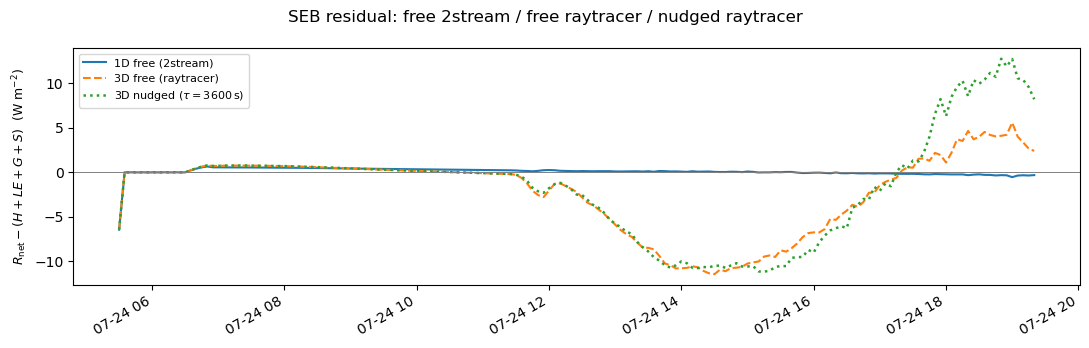

Saved seb_mean_state_nudge_residual.pdf


In [26]:
fig, ax = plt.subplots(figsize=(11, 3.5))

for run_key, sm, ss in run_data:
    resid = seb_residual({k: sm[k][:nt] for k in sm})
    sty   = STYLE[run_key]
    ax.plot(t_num, resid, label=LABEL[run_key], **sty)
    daytime = sm["Rnet"][:nt] > 50
    print(f"{LABEL[run_key]:40s}  "
          f"peak|resid|={np.abs(resid).max():5.1f}  "
          f"daytime_mean|resid|={np.abs(resid[daytime]).mean():5.1f} W m⁻²")

ax.axhline(0, color="gray", lw=0.7)
ax.set_ylabel(r"$R_\mathrm{net} - (H+LE+G+S)$  (W m$^{-2}$)", fontsize=9)
ax.legend(fontsize=8)
ax.xaxis_date()
ax.figure.autofmt_xdate()
fig.suptitle("SEB residual: free 2stream / free raytracer / nudged raytracer", fontsize=12)
plt.tight_layout()
plt.savefig("seb_mean_state_nudge_residual.pdf", bbox_inches="tight")
plt.show()
print("Saved seb_mean_state_nudge_residual.pdf")

## 4. Evaporative fraction (daytime) — absolute and % change from 1D

EF = LE / (H + LE).  Left panel: absolute EF for all three runs.
Right panel: (EF_3D − EF_1D) / EF_1D × 100 % — isolates the land-surface response to 3D RT.

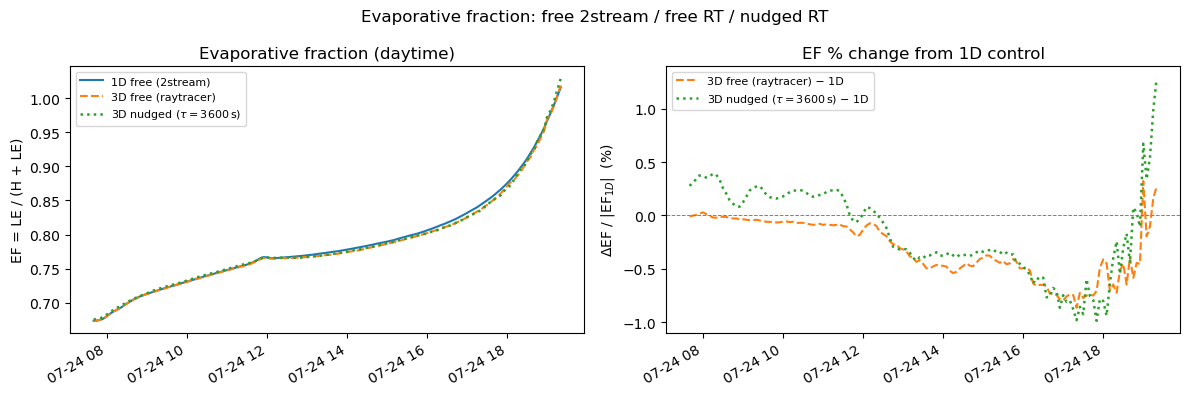

Saved seb_mean_state_nudge_ef.pdf


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Shared daytime mask from 1D control so arrays are always the same length
daytime = s2s_mean["Rnet"][:nt] > 50
t_day   = t_num[daytime]

ef_1d_day = evaporative_fraction({k: s2s_mean[k][:nt] for k in s2s_mean})[daytime]

for run_key, sm, ss in run_data:
    sm_t = {k: sm[k][:nt] for k in sm}
    ef   = evaporative_fraction(sm_t)[daytime]
    axes[0].plot(t_day, ef, label=LABEL[run_key], **STYLE[run_key])

for run_key in ["3D free", "3D nudged"]:
    sm   = next(sm for rk, sm, ss in run_data if rk == run_key)
    sm_t = {k: sm[k][:nt] for k in sm}
    ef   = evaporative_fraction(sm_t)[daytime]
    ef_pct = (ef - ef_1d_day) / np.abs(ef_1d_day) * 100
    axes[1].plot(t_day, ef_pct, label=f"{LABEL[run_key]} − 1D", **STYLE[run_key])

axes[0].set_ylabel("EF = LE / (H + LE)")
axes[0].set_title("Evaporative fraction (daytime)")
axes[0].legend(fontsize=8)

axes[1].axhline(0, color="gray", lw=0.7, ls="--")
axes[1].set_ylabel("ΔEF / |EF$_{1D}$|  (%)")
axes[1].set_title("EF % change from 1D control")
axes[1].legend(fontsize=8)

for ax in axes:
    ax.xaxis_date()
    ax.figure.autofmt_xdate()

fig.suptitle("Evaporative fraction: free 2stream / free RT / nudged RT", fontsize=12)
plt.tight_layout()
plt.savefig("seb_mean_state_nudge_ef.pdf", bbox_inches="tight")
plt.show()
print("Saved seb_mean_state_nudge_ef.pdf")

## 6. SEB conditioned on cloud mask — 1D free / 3D free / 3D nudged

At each timestep columns are split into **cloud-root** (`qlqi_path > 0`) and **cloud-free** columns.
Conditional means of H, LE, and SW↓ are shown for all three run types.

- **Left** panel: absolute timeseries (3 runs × 3 fluxes)
- **Right** panel: anomaly relative to 1D free control (shaded and cloud-free separately)

In [28]:
CACHE_DIR = Path(os.environ.get("SCRATCH", "/pscratch/sd/m/mpowell")) / "CASS_LES/analysis/seb_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def _compute_cond(result):
    """Eagerly materialise all lazy DataArrays in a conditioned-means result tuple."""
    mean_dict, std_dict = result
    for d in (mean_dict, std_dict):
        for kind in d:
            d[kind] = {var: da.compute() for var, da in d[kind].items()}
    return mean_dict, std_dict

def _load_or_compute_conditioned(rep_dirs, cache_name, variables, force=False):
    """Load conditioned ensemble means from pickle cache, or compute and cache."""
    cache_file = CACHE_DIR / f"{cache_name}.pkl"
    if not force and cache_file.exists():
        print(f"  [cache hit] {cache_file.name}")
        with open(cache_file, "rb") as fh:
            return pickle.load(fh)
    print(f"  [computing] {cache_name} …")
    result = _compute_cond(conditioned_means_ensemble(rep_dirs, variables=variables))
    with open(cache_file, "wb") as fh:
        pickle.dump(result, fh)
    print(f"  [cached]    {cache_file.name}")
    return result

_VARS_2S = ["thl_fluxbot", "qt_fluxbot", "sw_flux_dn"]
_VARS_RT = ["thl_fluxbot", "qt_fluxbot", "sw_flux_sfc_rt", "sw_flux_dn"]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    # Cache names match what seb.ipynb produces for no_aerosols_zero_wind
    cond_ctrl_2s_mean, cond_ctrl_2s_std = _load_or_compute_conditioned(
        dirs_2s,
        "experiments_no_aerosols_zero_wind__2stream",
        _VARS_2S,
    )
    cond_ctrl_rt_mean, cond_ctrl_rt_std = _load_or_compute_conditioned(
        dirs_rt,
        "experiments_no_aerosols_zero_wind__raytracer",
        _VARS_RT,
    )
    cond_nudge_mean, cond_nudge_std = _load_or_compute_conditioned(
        dirs_nudge,
        "experiments_mean_state_nudge_nudge_3600s__raytracer",
        _VARS_RT,
    )

print("All conditioned means ready.")

  [cache hit] experiments_no_aerosols_zero_wind__2stream.pkl
  [cache hit] experiments_no_aerosols_zero_wind__raytracer.pkl
  [cache hit] experiments_mean_state_nudge_nudge_3600s__raytracer.pkl
All conditioned means ready.


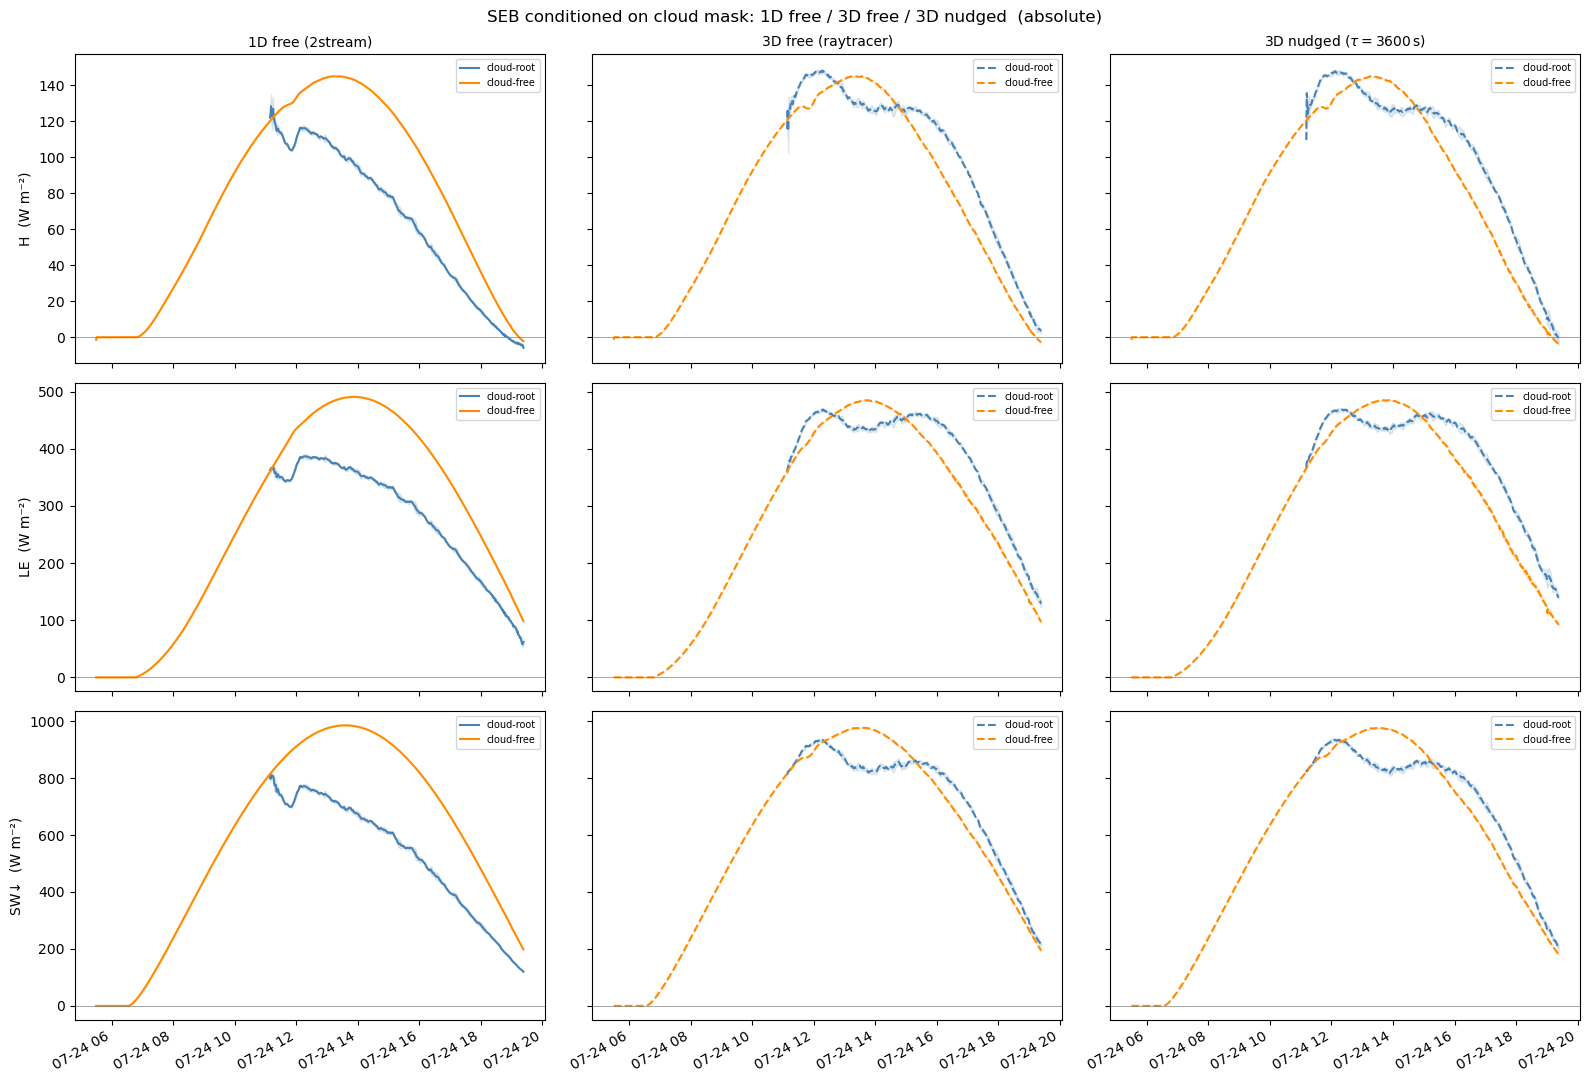

Saved seb_conditioned_absolute.pdf


In [29]:
H_scale  = rho * cp
LE_scale = rho * Lv

# (run_key, cond_mean, cond_std, rt_type_for_linestyle, sw_key)
_runs_cond = [
    ("1D free",   cond_ctrl_2s_mean, cond_ctrl_2s_std, "2stream",   "sw_flux_dn"),
    ("3D free",   cond_ctrl_rt_mean, cond_ctrl_rt_std, "raytracer", "sw_flux_sfc_rt"),
    ("3D nudged", cond_nudge_mean,   cond_nudge_std,   "raytracer", "sw_flux_sfc_rt"),
]
_row_info = [
    ("thl_fluxbot", H_scale,  "H  (W m⁻²)"),
    ("qt_fluxbot",  LE_scale, "LE  (W m⁻²)"),
    (None,          1.0,      "SW↓  (W m⁻²)"),   # sw_key chosen per column
]

fig, axes = plt.subplots(3, 3, figsize=(16, 11), sharex=True, sharey="row")

for col, (run_key, cm, cs, rt_type, sw_key_col) in enumerate(_runs_cond):
    t_local = cm["shaded"]["thl_fluxbot"].time.values
    for row, (var_key, scale, ylabel) in enumerate(_row_info):
        ax   = axes[row, col]
        vkey = sw_key_col if var_key is None else var_key
        plot_flux_conditioned(
            ax, t_local,
            cm["shaded"][vkey],  cm["unshaded"][vkey],
            cs["shaded"].get(vkey), cs["unshaded"].get(vkey),
            rt_type=rt_type, ylabel=ylabel if col == 0 else "", scale=scale,
        )
        if row == 0:
            ax.set_title(LABEL[run_key], fontsize=10)
        if col > 0:
            ax.set_ylabel("")
        ax.legend(fontsize=7)

fig.suptitle("SEB conditioned on cloud mask: 1D free / 3D free / 3D nudged  (absolute)", fontsize=12)
plt.tight_layout()
plt.savefig("seb_conditioned_absolute.pdf", bbox_inches="tight")
plt.show()
print("Saved seb_conditioned_absolute.pdf")

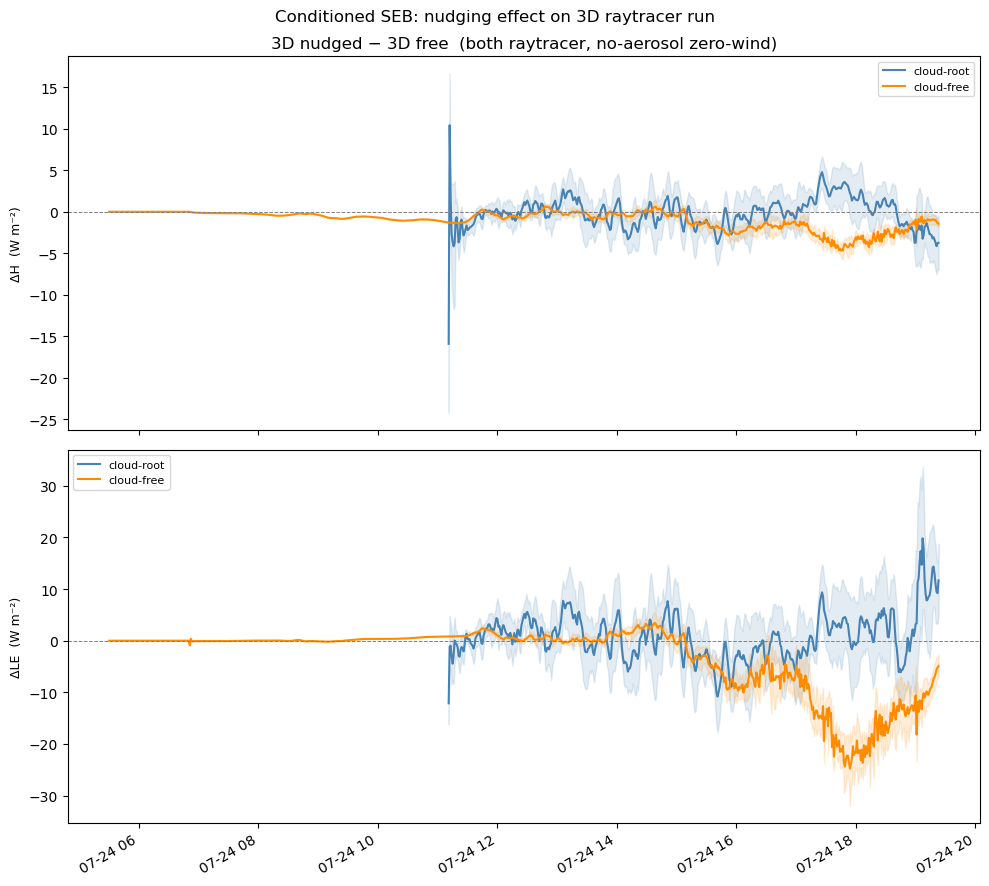

Saved seb_conditioned_nudge_vs_free.pdf


In [32]:
# Anomaly: 3D nudged − 3D free, for each flux, split by cloud-root vs cloud-free.
# Both runs are raytracer so SW uses sw_flux_sfc_rt.
_nudge_anom_rows = [
    ("thl_fluxbot",  H_scale,  "ΔH  (W m⁻²)"),
    ("qt_fluxbot",   LE_scale, "ΔLE  (W m⁻²)"),
]

# Align time
_nt_rt = min(
    cond_ctrl_rt_mean["shaded"]["thl_fluxbot"].sizes["time"],
    cond_nudge_mean["shaded"]["thl_fluxbot"].sizes["time"],
)
_t_rt  = cond_ctrl_rt_mean["shaded"]["thl_fluxbot"].time.values[:_nt_rt]
_t_num_rt = _to_plottime(_t_rt)

fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True)

for ax, (var_key, scale, ylabel) in zip(axes, _nudge_anom_rows):
    for kind, color, kind_label in [("shaded", "steelblue", "cloud-root"), ("unshaded", "darkorange", "cloud-free")]:
        y_free  = np.asarray(cond_ctrl_rt_mean[kind][var_key].isel(time=slice(None, _nt_rt))) * scale
        y_nudge = np.asarray(cond_nudge_mean[kind][var_key].isel(time=slice(None, _nt_rt)))   * scale
        diff    = y_nudge - y_free

        err_free  = np.asarray(cond_ctrl_rt_std[kind][var_key].isel(time=slice(None, _nt_rt))) * scale
        err_nudge = np.asarray(cond_nudge_std[kind][var_key].isel(time=slice(None, _nt_rt)))   * scale
        err_diff  = np.sqrt(err_free**2 + err_nudge**2)

        ax.plot(_t_num_rt, diff, color=color, label=kind_label)
        ax.fill_between(_t_num_rt, diff - err_diff, diff + err_diff, color=color, alpha=0.15)

    ax.axhline(0, color="gray", lw=0.7, ls="--")
    ax.set_ylabel(ylabel, fontsize=9)
    ax.xaxis_date()
    ax.figure.autofmt_xdate()
    ax.legend(fontsize=8)

axes[0].set_title("3D nudged − 3D free  (both raytracer, no-aerosol zero-wind)")
fig.suptitle("Conditioned SEB: nudging effect on 3D raytracer run", fontsize=12)
plt.tight_layout()
plt.savefig("seb_conditioned_nudge_vs_free.pdf", bbox_inches="tight")
plt.show()
print("Saved seb_conditioned_nudge_vs_free.pdf")